# Markov decision processes 

In our previous notebook we dealt with "stationary" problems like the Multi-Armed bandit: the actions performed by the agent would not change the state of the system. But, as we saw in the few examples, this is almost never the case. In most typical RL scenarios, the actions taken by the agent will affect the state of the environment, and the agent has to adapt its behavior accordingly. This interaction is modeled using Markov Decision Processes (MDPs). 

## Elements of a MDP

::: {#fig-mdp}
<img src="../../figures/mdp.svg" width="30%"/>

An example of a Markov Decision Process. Adapted from [Wikipedia](https://es.wikipedia.org/wiki/Archivo:Markov_Decision_Process.svg)
:::

The main feature of an MDP is that it follows the *Markov property*, namely

\begin{equation}
p(s_{t+1}|s_t, s_{t-1}, \dots, s_0) = p(s_{t+1}|s_t)
\end{equation}


As you can see in @fig-mdp, a MDP is defined by the following elements:

- A set of states $S$. 
- A set of actions $A$.
- A transition probability function $p(s',r|s,a)$ representing the probability of reaching state $s'$ and receiving reward $r$ when taking action $a$ in state $s$.
- A reward function $R(s,a)$ representing the reward received when taking action $a$ in state $s$.

From this, the entire dynamics of the MDP are characterized. In particular, we can calculate the *state-transition* probability as

\begin{equation}
p(s'|s,a) = \sum_{r} p(s',r|s,a)
\end{equation}

Coming back to our RL's ingredients, we know that the RL agent is equipped with a policy $\pi(a|s)$, defining the probability of taking action $a$ when in state $s$. The interaction of the agent with the environment generate trajectories

\begin{equation}
s_0, a_0, r_1, s_1, a_1, r_2, s_2, a_2, r_3, \dots
\end{equation}

If we focus only on the trajectory through the state-action space $\tau = (s_0, a_0, s_1, a_1, s_2, a_2, \dots, s_T)$, its probability is given by

\begin{equation}
p(\tau) = \prod_{t=0}^{T-1} p(s_{t+1}|s_t, a_t)\pi(a_t|s_t)
\end{equation}


Similarly, we can calculate the discounter return asociated with the previous trajectory $\tau$ as

\begin{equation}
G(\gamma) = \prod_{t=0}^{T-1} \gamma^t r_{t+1}
\end{equation}

## Value functions and Bellman equations

:::{callout-note}
See Sec. 6.1.5 of the [Machine Learning in Quantum Sciences book](https://arxiv.org/pdf/2204.04198#page=143) for a detailed version of this section.
:::

Value functions quantify how good it is for an agent to be in a state or to take an action when following a policy. For a given policy $\pi(a|s)$, the *state-value* function is defined as

\begin{equation}
v_\pi(s) = \mathbb{E} \bigl[ G_t \mid S_t = s, \pi \bigr] = \mathbb{E}\bigl[ \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s , \pi \bigr].
\end{equation}

Similarly, one can write the action-value function as

\begin{equation}
q_\pi(s,a) = \mathbb{E} \bigl[ G_t \mid S_t = s, A_t = a, \pi \bigr]= \mathbb{E}\bigl[ \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s, A_t = a , \pi \bigr].
\end{equation}

These concepts introduce a partial ordering between policies. A policy $\pi$ is better than another policy $\pi'$ if it yields a higher return. Formally,
$\pi > \pi'$ iff $V_\pi(s) > V_{\pi'}(s)$ for all $s \in S$, i.e. $v^*=\max_\pi v_\pi(s)$, and similarly for $q$. Therefore, the optimal policy $\pi^*$ is the one that is better than or equal to every other policy. In other words, the optimal policy is the policy that maximizes the value function. Using the recursive nature of the value functions, we can write the *Bellman optimality equations*:

\begin{equation}
v^*(s) = \max_{a} \sum_{s',r} p(s',r|s,a) \bigl[ r + \gamma v^*(s') \bigr]
\end{equation}

\begin{equation}
q^*(s,a) = \sum_{s',r} p(s',r|s,a) \bigl[ r + \gamma \max_{a'} q^*(s',a') \bigr]
\end{equation}


:::{callout-important}
Value-based methods revolve around the Bellman equations, using them to estimate value functions and derive improved policies, and will be the focus through this course. **However,**  many other approaches exist: from policy-based methods, which directly optimize the policy, to actor–critic methods, which combine value estimation with policy optimization or model-based variants further incorporate an explicit model of the environment’s dynamics to plan ahead and improve decision making. You can find details about this in Sec. 6 of the [Machine Learning in Quantum Sciences book](https://arxiv.org/pdf/2204.04198#page=143)
:::

# Value-based methods

In value-based RL, the goal is to obtain the optimal policy $\pi^∗(a|s)$ by learning the optimal value functions. This way, we start with an initial estimation of the value function for every state, $V_\pi(s)$, or state−action pairs, $Q_\pi(s, a)$. Then, we progressively update them with the experience gathered by the agent following its policy.

A simple approach to value-based RL would be to sample a trajetory $\tau$ as we did above, compute its return $G_\tau$ and update our value function estimation along every visited state $s_t$:

\begin{equation}
V_\pi(s_t) \leftarrow V_\pi(s_t) + \eta \bigl( G_\tau - V_\pi(s_t) \bigr)
\end{equation}

However, with this approach we need to wait until the end of the episode to compute the return $G_\tau$... Instead, temporal-difference (TD) learning methods allow us to update our value function estimation at every step, without waiting until the end of the episode. This is done by using the observed reward and the estimated value of the next state to compute a TD target:

\begin{equation}
V_\pi(s_t) \leftarrow V_\pi(s_t) + \eta \bigl[ r_{t+1} + \gamma V_\pi(s_{t+1}) - V_\pi(s_t) \bigr]
\end{equation}

where the term in brackets is typically called the TD error. The previous equation is known as the TD(0) update rule. Similarly, we can write a TD update rule for the action-value function:

\begin{equation}
Q_\pi(s_t, a_t) \leftarrow Q_\pi(s_t, a_t) + \eta \bigl[ r_{t+1} + \gamma Q_\pi(s_{t+1}, a_{t+1}) - Q_\pi(s_t, a_t) \bigr]
\end{equation}

From the previous equation emerge two different approaches to value-based RL: SARSA and Q-learning (see [THE RL book](http://incompleteideas.net/book/the-book-2nd.html) by Sutton and Barto for more). While very similar, they have a very important different: in SARSA, the update uses the action $a_{t+1}$ actually taken by the agent in state $s_{t+1}$ (i.e. exactly the previous equation or similar versions), while in Q-learning, the update uses the action that maximizes the action-value function in state $s_{t+1}$. This makes Q-learning an *off-policy* method, while SARSA is an *on-policy* one. Let's see in detail the former, as it is one of the most popular RL algorithms.

## Q-learning

Most of the TD algorithms that we introduce in the previous section learn the value functions for their given policies, mainly ε-greedy policies. These include exploratory random actions that have an impact on the learned value functions. Therefore, the policy determines the result, and we must adjust ε during the training process to ensure their proper convergence toward the optimal value functions. However, due to its **off-policy** nature, Q-learning always learns the optimal action-value function regardless of the policy followed during the training.

Given an initial $Q(s,a)$, the Q-learning algorithm updates it at each time step $t$ according to the following rule:

\begin{equation}
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \eta \bigl[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t) \bigr],
\end{equation}
where $\eta$ is the learning rate, $r_{t+1}$ is the reward received after taking action $a_t$ in state $s_t$, and $\gamma$ is the discount factor.

This method is guaranteed to converge to the optimal action-value function as long as all possible state−action pairs continue to be updated. This is a necessary condition for all the algorithms that converge to the optimal behavior and it can become an issue for fully deterministic policies. However, with Q-learning, we can have an ε-greedy policy with $\epsilon = 0$ that ensures that this condition is fulfilled.

The key element is that, while the policy determines which states and actions are visited by the agent, the Q-value update is performed over a greedy next action. This way, the learned Q-values are those corresponding to the greedy policy over them, which is the one fulfilling the Bellman optimality equations. The pseudo-code looks like this:

::: {#fig-qlearning}
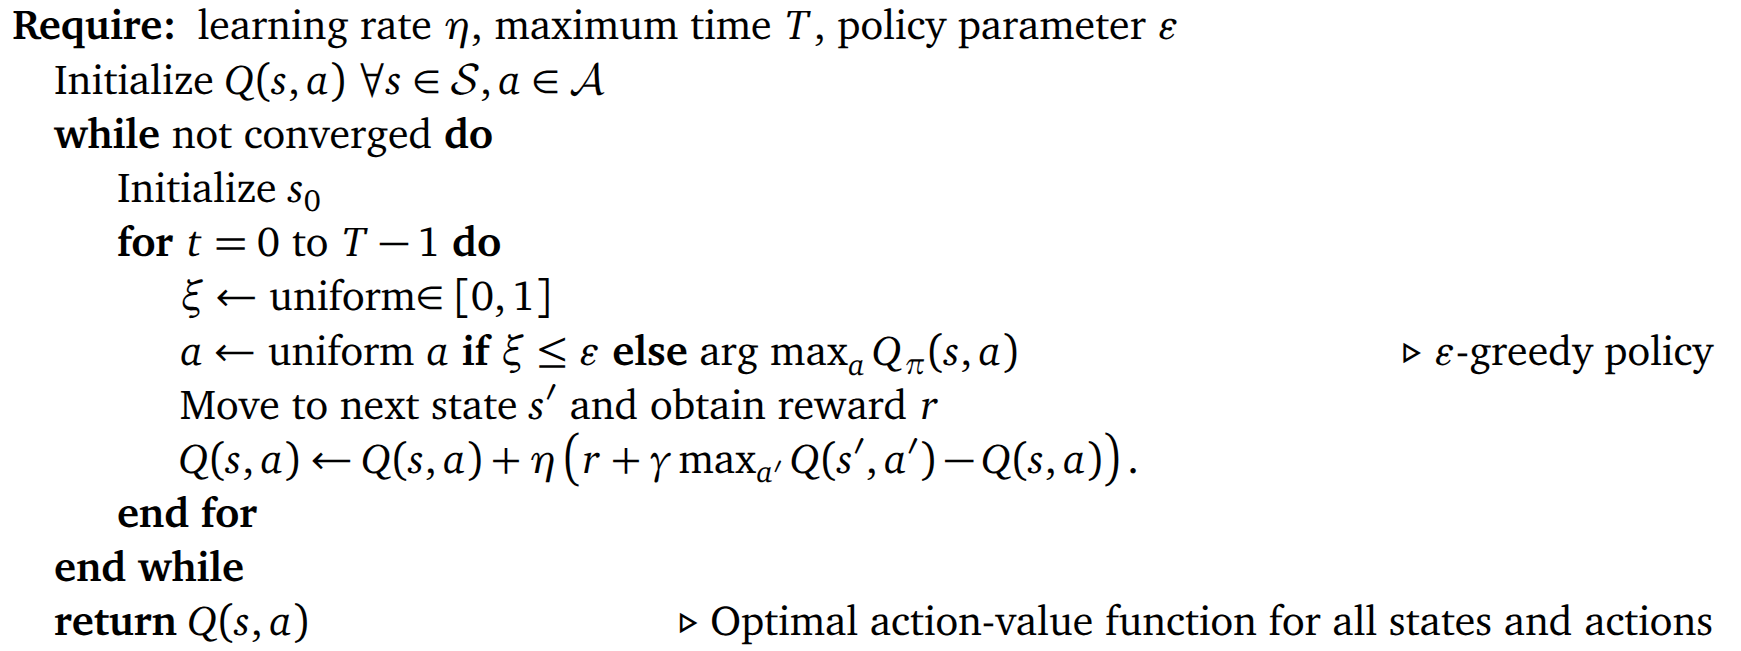

Q-learning pseudo-code, from the [Machine Learning in Quantum Sciences book](https://arxiv.org/pdf/2204.04198#page=143).
:::


### Example 

Let us create a dummy environment and see how to implement the above pseudocode with `numpy` (`pytorch` would also be fine!).

In [1]:
import numpy as np

class dummy_env:
    # This environment will just give us random states given any action.

    def __init__(self, num_states = 5):
        self.num_states = num_states
        pass
    
    def step(self, action):
        # In most RL environments, the function that receives an action
        # and implements it in the environment is called step. It then 
        # returns the new state and the reward (let's consider it as 1 
        # for this example
        return np.random.randint(self.num_states), 1

    def reset(self):
        # The reset module is used to bring back the environment to the starting
        # state. In this case we also pick that as random
        return np.random.randint(self.num_states)

env = dummy_env()

We now initialize the algorithm's parameters as well as the Q-matrix:

In [2]:
# We start by defining the number of states (given typically by the environment) 
# and the number of actions (a random number in this example)
num_states = env.num_states
num_actions = 3
# We also define the algorithm's parameters
eta = 1
epsilon = 0.3
gamma = 0.5

# Initialize Q table with all zeros
Q = np.zeros([num_states, num_actions])

# We also initialize the env to get the starting state:
s0 = env.reset()

Now we just need to follow the previous pseudocode:

In [3]:
# We check for the greedy step:
if epsilon < np.random.rand():
    # random action
    action = np.random.randint(num_actions)
else:
    # greedy action
    action = np.argmax(Q[s0, :])

# We now perform the action in the environment, and get a new state and reward
new_state, reward = env.step(action)

# With this, we are ready to update our Q-matrix
Q[s0,action] = Q[s0,action] + eta*(reward + gamma*np.max(Q[new_state,:]) - Q[s0,action])

s0, action, Q

(4,
 2,
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 1.]]))

As you can see, the Q-matrix has been update according to the current state and action! In practice, the previous is run over multiple *episodes* (what we called before epochs). Each episode typically starts in the initial state (i.e. we run `env.reset`), and runs until we either: 1) reach the target state; 2) reach the maximum number of steps per episode previously define ($T$ in the pseudocode above); 3) We reach a "done" state, i.e. a particular state in which the agent is considered to have failed in some way and needs to restart from the beginning (i.e. loosing a chess match). Let's see all that through an exercise:


::: {.callout-tip}
## Exercise

Implement the Q-learning algorithm in the Frozen Lake environment. For that, first need to install `pip install gymnasium`. You can find all details in the [environment documentation](https://gymnasium.farama.org/environments/toy_text/frozen_lake/). Then, you can load the environment using :

In [4]:
import gymnasium as gym

env = gym.make('FrozenLake-v1', render_mode="ansi", is_slippery = False)

# gymnasium environments need to be reset before any use. 
# They also allow for some rendering of the 
env.reset()
print(env.render())


SFFF
FHFH
FFFH
HFFG



You can also get the size of the state and action spaces using:

In [5]:
env.observation_space.n, env.action_space.n

(np.int64(16), np.int64(4))

To perform actions, we use again the `env.step` function, which in this case returns the next state, the reward, a boolean stating if the episode is done or not (e.g. because the agent fell in the lake or got the reward). The rest of the `env-step` output is not needed for this example.

In [6]:
next_state, reward, done, _, _ = env.step(2)
print(next_state, reward, done)
print(env.render())

1 0 False
  (Right)
SFFF
FHFH
FFFH
HFFG



Based on this, train a Q-learning agent. As a tip, the following training parameters should give you a nice result:

In [7]:
eta = 0.8
gamma = 0.9

Track two variables: 

1) The rewards you obtain per episode.
2) The number of steps performed at each episode.

Plot these two variables through a moving average over your episodes.

:::

In [8]:
#| code-fold: true
#| code-summary: Solution - Training

def train_q_table(env, num_episodes, eta, gamma, max_t=99):
    """Q-table algorithm implementation."""
    # Initialize Q table
    Q = np.zeros([env.observation_space.n, env.action_space.n])
    # Instantiate a couple of lists to keep track of progress
    time_steps = []
    rewards = []
  
    for i in range(num_episodes):
        # Reset environment and initialize all variables
        s = env.reset()[0]
        r = 0
        done = False
        # The Q-Table learning algorithm
        for j in range(max_t):
            # Choose an action greedily (with noise) picking from Q table.
            # We can alternatively use an epsilon-greedy policy
            a = np.argmax(Q[s,:] + np.random.randn(1, env.action_space.n)*(1./(i+1)))
            #Get new state and reward from environment
            s1, r, done, _, _ = env.step(a)
            #Update Q-Table with new knowledge
            Q[s,a] = Q[s,a] + eta*(r + gamma*np.max(Q[s1,:]) - Q[s,a])

            s = s1
            if done == True:
                break
        
        time_steps.append(j + 1)
        rewards.append(r)
      
    return Q, time_steps, rewards

In [9]:
#| code-fold: true
#| code-summary: Solution - Average over multiple runs
from tqdm import tqdm

# Set learning rate and discount factor parameters
eta = 0.8
gamma = 0.9

# Runs of the algorithm and episodes of each run
runs = 30
num_episodes = 500

steps, rewards, Qs = [], [], []
for _ in tqdm(range(runs)):
    Q, time_steps, obtained_rewards = train_q_table(env, num_episodes, eta, gamma)

    Qs.append(Q)
    steps.append(time_steps)
    rewards.append(obtained_rewards)

100%|██████████| 30/30 [00:01<00:00, 22.93it/s]


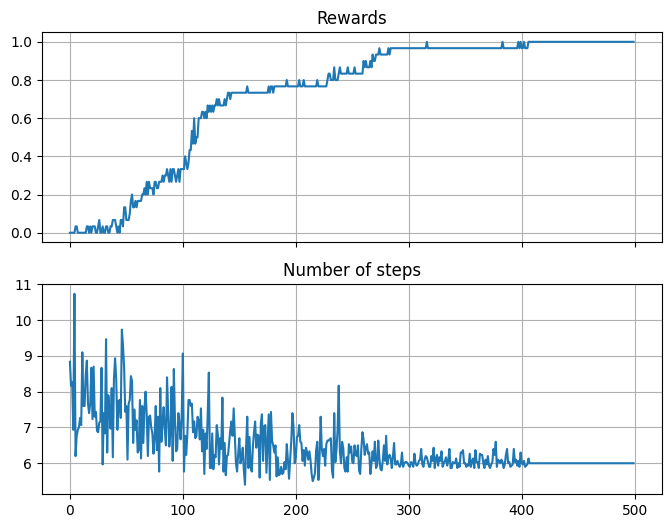

In [10]:
#| code-fold: true
#| code-summary: Solution - Plot

import matplotlib.pyplot as plt

avg_steps = np.mean(steps, 0)
avg_rewards = np.mean(rewards, 0)

f, axes = plt.subplots(2, sharex=True, figsize=(8, 6))
axes[0].plot(avg_rewards)
axes[0].grid()
axes[0].set_title('Rewards')
axes[1].plot(avg_steps)
axes[1].grid()
axes[1].set_title('Number of steps');

## Projective simulation

Projective Simulation (PS) ([Briegel and De Las Cuevas (2012)](https://www.nature.com/articles/srep00400)) is an alternative approach value-based RL approach that is inspired by physical processes. For a wider introduction to it and a coverage of its application, you can visit our library [`projective_simulation`](https://github.com/qic-ibk/projective_simulation/).

In PS, the agent's memory is represented as a network of interconnected nodes, which are small units of information that can represent percepts, actions, or more complex concepts. The network is called the episodic and composition memory (ECM) and in its most general form, looks like this:

::: {#fig-mdp}
<img src="../../figures/ps_deep.svg" width="60%"/>

An example of a Episodic and Compositional Memory (ECM), with two states clips, three hidden clips and three action clips.
:::

The nodes, defined here as clips, represent either visited states or actions, but also hidden information learnt by the agent. As it explores the environment and new states are visited, nodes representing these are added to the graph. Similarly, an agent may create new nodes to accommodate new actions or new hidden information. The edges account for the hopping probabilities between the nodes. This means that, when observing a certain state, the agent is set in the node representing it and then, following the hopping probabilities, walks through the ECM until reaching a node representing an action, which is then performed by the agent over the environment.

Following the previous scheme, training a PS agent is done by the update of the edge values, also referred to as the $h$-values. The updates have to be made such that, for every visited state, the path through the ECM leads to the correct action. The training of PS can then be reduced to the update of the $h$-values via
\begin{equation}
	h(c_i, c_j) \leftarrow h(c_i, c_j) - \gamma (h(c_i, c_j)-1) + R
\end{equation}
where $c_i$ and $c_j$ represent the nodes (clips) $i$ and $j$, $\gamma$ is a damping parameter and R is the reward given by the environment. As it can be seen, the previous update leads to unnormalized $h$-values. The hopping probability, for instance of $c_i$ to $c_j$ is calculated using
\begin{equation}
	P(c_i, c_j) = \frac{h(c_i, c_j)}{\sum_{k\in \mathcal{I}}h(c_i, c_k)},
\end{equation}
where $\mathcal{I}$ is the set of nodes in the ECM connected to the node $i$.

At every agent’s step, i.e. every time it interacts with the environment, all $h$-values are updated. However, the last term of the update equation, related to the state-action reward, is only added to the edges that were traversed in the very last step. In this way, all $h$-values are damped with a fact $\gamma$, while the edges that led to rewarded actions increase their values by a factor $R$.

In many practical scenarios, rewards are obtained at the end of a long series of actions, i.e. performing various steps in a grid-world to reach a target. Hence, it is important to “*backpropagate*” such reward to all the actions that led to it. For instance, in Q-learning, such problem is solved by consider the expected value of future states when updating the Q-matrix. To accommodate such property, we can generalize the update rule above by adding the concept of *edge glow*. This feature allows the agent to internally reward all the edges that were traversed during the deliberations that led to receiving a reward $R$. The update rule can then be rewritten as 
\begin{equation}
	h(c_i, c_j) \leftarrow h(c_i, c_j) - \gamma (h(c_i, c_j)-1) + g(c_i, c_j)\cdot R
\end{equation}
where $g$ is the glow value. The latter is a matrix of same size as $h$. Each time a certain edge is visited, it’s corresponding $g$-value is set to 1. Then, at every step, the glow matrix is update via
\begin{equation}
	g(c_i, c_j) \leftarrow g(c_i, c_j)(1-\eta),
\end{equation}
which effectively decreases all its values with a rate $\eta$. This means that edges that were recently visited and led to a reward $R\neq 0$ will be strengthened while the rest of the $g$-values sequentially decay. Importantly, the g-matrix is reset to zeros after each episode, so that the glow does not propagate between episodes.

As you can see, Q-learning and PS update their values in "opposed" temporal way, as PS will update all the edges that led to a reward, while Q-learning updates based a given state-action pair considering the *expected* future rewards.

An important feature of the PS model is it's transparency and potential interpretable power. In Q-learning, the Q-matrix encodes the expected reward received from an action-state tuple. As the policy relies on performing the action with largest Q-value, there is little to no room from interpretability, aside of such maximization. On the other hand, PS constructs a visible graph which ultimately encodes the probabilities of hopping between its various nodes, which, as commented previously, may represent both direct information from the RL task (i.e. actions and states) but also hidden information. This is currently under investigation :P .

### 2-layer PS
In typical RL contexts, a 2-layer ECM is normally enough, although at the expense of the PS interpretability power.  In this case, the ECM is composed of a first layer of percept clips (i.e. states) and a second layer of action clips. The hopping probabilities are then defined only between these two layers. The update rules remain the same, but now the indices $i$ and $j$ in the previous equations only run over percepts and actions respectively. Here is an schematic of a 2-layer PS agent:

::: {#fig-mdp}
<img src="../../figures/2_layer_ps.svg" width="50%"/>

A two layer Episodic and Compositional Memory (ECM), with $n$ states clips and $m$ action clips.
:::

While this implementation does not come with inherent interpretability, it is simpler to implement and can achieve good results in many RL tasks. Let's see how to implement it through an exercise.

::: {.callout-tip}
## Exercise

- **Step 1**: implement a 2-layer PS agent with glow. For that, create a class `PS_agent` that has (at least) the following methods: `learn` (used to update the $h$-matrix) and `deliberate` (used to select an action given a state).
- **Step 2**: create a training loop for the PS agent in the Frozen Lake environment created above, similar to the one you did for Q-learning. Tip: remember that the $g$-matrix has to be reset at the beginning of each episode. For the hyperparameters, $\gamma = 0$ and $\eta = 0.04$ should give you a nice result.

**Bonus**:  Try to average your results over multiple runs, and plot the average rewards and steps per episode. Compare with the results you got with Q-learning.
:::

In [11]:
#| code-fold: true
#| code-summary: Solution - PS agent
class PS_agent:
    gamma : float
    eta : float
    def __init__(self, gamma, eta, num_states, num_actions):
        self.gamma = gamma
        self.eta = eta

        self.hmatrix = np.ones((num_states, num_actions))

        self.reset_gmatrix()

    def reset_gmatrix(self):
        self.gmatrix = np.zeros_like(self.hmatrix)
        
    def update_gmatrix(self):
        self.gmatrix *= (1 - self.eta)
        return self.gmatrix
    
    def learn(self, reward):    
        self.hmatrix = self.hmatrix - self.gamma * (self.hmatrix - 1) + self.gmatrix * reward

    def deliberate(self, state):
        # Compute probabilities for current action and sample        
        # probs_a = softmax(self.hmatrix[state, :])
        probs_a = self.hmatrix[state, :] / np.sum(self.hmatrix[state, :])
        action = np.random.choice(np.arange(len(probs_a)), p=probs_a)
        
        # Update glow matrix
        self.update_gmatrix()
        self.gmatrix[state, action] = 1

        return action
        
ps_agent = PS_agent(gamma=0.9, eta=0.1, num_states=5, num_actions=3)

In [19]:
#| code-fold: true
#| code-summary: Solution - PS Training loop
def train_ps(gamma, eta, episodes):
    
    
    env = gym.make('FrozenLake-v1', render_mode="ansi", is_slippery = False)
    
    ps_agent = PS_agent(gamma=gamma, eta=eta, 
                        num_states=env.observation_space.n, 
                        num_actions=env.action_space.n)    
 
    
    max_t = 99    
    time_steps = []
    rewards = []
    
    for t in range(episodes):
    
        s = env.reset()[0]
        r = 0
        done = False
    
        ps_agent.reset_gmatrix()
        
        for j in range(max_t):
    
            action = ps_agent.deliberate(s)        
            s1, r, done, _, _ = env.step(action)
            ps_agent.learn(r)

            s = s1
            if done == True:
                break
                
        time_steps.append(j + 1)
        rewards.append(r)
    
    return ps_agent.hmatrix, ps_agent.gmatrix, time_steps, rewards

    

gamma = 1e-7; eta = 0.006

runs = 30
episodes = 500
steps, rewards = [], []
for i in tqdm(range(runs)):
    _, _, time_steps, obtained_rewards = train_ps(gamma, eta, episodes)
    # _, _, time_steps, obtained_rewards = train_ps_from_lib(gamma, eta, episodes)

    steps.append(time_steps)
    rewards.append(obtained_rewards)


100%|██████████| 30/30 [00:04<00:00,  7.23it/s]


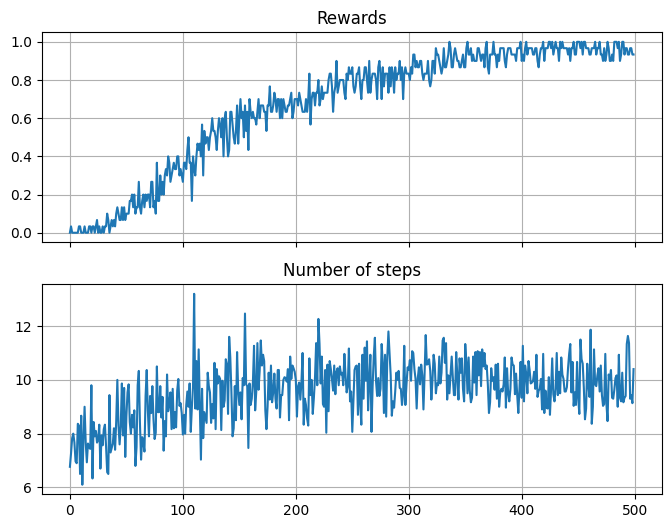

In [20]:
#| code-fold: true
#| code-summary: Solution - Averaging Plot

import matplotlib.pyplot as plt

avg_steps = np.mean(steps, 0)
avg_rewards = np.mean(rewards, 0)

f, axes = plt.subplots(2, sharex=True, figsize=(8, 6))
axes[0].plot(avg_rewards)
axes[0].grid()
axes[0].set_title('Rewards')
axes[1].plot(avg_steps)
axes[1].grid()
axes[1].set_title('Number of steps');


# Deep RL

Until now we have focused on what is usually refer to as "tabular" methods: those in which the values are store either in matrices (Q-learning) or graphs (PS). However, these methods face some limitations, mostly when facing real world problems:

- They can only work with a finite set of states, i.e. those stored in their tables. Moreover, the size of their tables will increase with the number of states, leading to memory issues. This has two big implications:
    - They cannot work with continuous state spaces, as they require a discrete set of states to store their values.
    - They cannot generalize to unseen states, as they only store values for the states they have visited.
- Similarly, these methods don't work with continuous action spaces, as they require a discrete set of actions to store their values.

Due to this, researchers have developed variants of RL that use instead a neural network withing their policy. Here we will explore a "neural network" upgrade of Q-learning, the Deep Q-Network (DQN) algorithm.

::: {.callout-important}
In this course we will always consider a finite, discrete set of actions. However, many real-world problems involve continuous action spaces. To handle such scenarios, alternative algorithms like Deep Deterministic Policy Gradient (DDPG) or Proximal Policy Optimization (PPO) are often employed.
:::

## Deep Q-network 

The goal of DQN is to approximate the optimal action-value function $Q^*(s,a)$ using a neural network. This network, parameterized by weights $\theta$, takes as input the state $s$ and outputs the Q-values for all possible actions $a$:

::: {#fig-mdp}
<img src="../../figures/dqn.svg" width="50%"/>

Schematic of a NN for DQN.
:::

Now the challenge comes with training this neural network. In previous lectures, we have seen how to train the network in a supervised way. But here, we don't have access to the optimal $Q^*(s,a)$ we aim to approximate, only to the rewards obtained by the agent. The idea is to use the Bellman optimality equation as a target for the network's predictions:

\begin{equation}
\text{loss} =
\underbrace{r_t + \gamma \max_{a'} Q_{\text{NN}}(s_{t+1}, a')}_{\text{target}}
\;-\;
\underbrace{Q_{\text{NN}}(s_t, a_t)}_{\text{prediction}}
\end{equation}

This loss measures how different the network’s current prediction is from the Bellman target. By minimizing it with gradient descent, we push the network toward values that satisfy the Bellman optimality equation. In practice, this means that after taking an action and observing the next state and reward, we update the network so that its estimate $Q_{\text{NN}}(s_t, a_t)$ moves closer to the one-step optimal return.

This procedure is the core idea behind Deep Q-Learning (DQN): we use a neural network to approximate the Q-function, and we train it by repeatedly applying these Bellman-based updates. Although conceptually simple, this approach requires some additional techniques to stabilize learning in practice, such as experience replay (to decorrelate samples) and the use of a separate target network (to avoid chasing a moving target).

::: {.callout-tip}
## Exercise - DQN 1
Let's built, step by step, the different modules of a DQN agent.  First, implement a simple feedforward neural network using `pytorch` that takes as input the state and outputs the Q-values for all possible actions. Let's for the moment just consider two linear layers, and variable state dimension and number of actions.

In [2]:
import torch
import torch.nn as nn

class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)

Now, given this network, and that you get as input the tuple $(s_t, a_t, r_t, s_{t+1})$, create a function that computes the loss and updates the network. 

> **Important:**
> 1) Make sure that the computation of the target does not affect the computation of the gradients (i.e. use `torch.no_grad`)
> 2) When reaching a final state (i.e. done = True), the target should be just the reward, without considering the next state (i.e. neglect the $\gamma \max_{a'}...$ term).

You can the use the following cell to test your implementation.

In [6]:
# Some random states / actions
state_size = 10
num_actions = 5
s      = torch.rand(state_size)
a      = torch.randint(0, num_actions, (1,))       # action is an integer index
r      = torch.rand(1)
s2     = torch.rand(state_size)
done   = False    # 1.0 if terminal, else 0.0

# Define the network and optimizer
q_net = QNetwork(state_dim = s.shape[0], n_actions = 5)
optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-3)
gamma = 0.99

loss, pred, target = QNetwork_update(q_net, optimizer, s, a, r, s2, done)
print("Loss:", loss)
print("Q(s,a) before update:", pred)
print("Bellman target:", target)

Loss: -0.4920838475227356
Q(s,a) before update: -0.021764785051345825
Bellman target: 0.47031906247138977


:::

In [5]:
#| code-fold: true
#| code-summary: Solution - DQN update method

def QNetwork_update(q_net, optimizer, s, a, r, s2, done, gamma=0.99):
    # 1) Q(s, ·)
    q_values = q_net(s.unsqueeze(0))        # shape (1, n_actions)
    q_sa = q_values[0, a]                   # Q(s, a)
    
    # 2) target: r + γ * max_a' Q(s2, a')     (unless done)
    with torch.no_grad():
        next_q = q_net(s2.unsqueeze(0))
        max_next_q = next_q.max(dim=1).values[0]
        target = r + gamma * (1-done)*max_next_q

    # 3) While we talked about the loss as:
    loss = target - q_sa

    ''' It is often better to defined it as the MSE between prediction and target:'''
    # loss = torch.nn.functional.mse_loss(q_sa, target)

    # 4) Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item(), q_sa.item(), target.item()

# Some random states / actions
s      = torch.tensor([0.1, 0.3, -0.2, 0.7], dtype=torch.float32)
a      = torch.tensor(1)       # action is an integer index
r      = torch.tensor(1.0)
s2     = torch.tensor([0.0, -0.4, 0.5, 0.1], dtype=torch.float32)
done   = torch.tensor(0.0)     # 1.0 if terminal, else 0.0

# Define the network
q_net = QNetwork(state_dim = s.shape[0], n_actions = 5)
optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-3)
gamma = 0.99

loss, pred, target = QNetwork_update(q_net, optimizer, s, a, r, s2, done)
print("Loss:", loss)
print("Q(s,a) before update:", pred)
print("Bellman target:", target)


Loss: -1.27018404006958
Q(s,a) before update: -0.1029624491930008
Bellman target: 1.1672215461730957


### Replay

From the previous, we can see that training a DQN agent involves updating the neural network after every action taken by the agent. However, this can lead to instability and divergence during training, as the network is constantly chasing a moving target. This is indeed analogous to training with a very small batch size of 1. In practice, in DQN we first gather "experiences", by letting the agent interact with the environment, and store the tuples $(s_t, a_t, r_t, s_{t+1})$ in a replay buffer (a memory). Then, during training, we sample random batches of experiences from this buffer to update the network. This breaks the strong temporal correlations that arise when learning directly from consecutive steps of the agent’s trajectory and greatly improves training stability. It also allows each experience to be reused multiple times, increasing data efficiency.

### Double DQN

A practical issue with DQN is that the maximization step

\begin{equation}
\max_{a'} Q(s_{t+1}, a')
\end{equation}

tends to produce overoptimistic value estimates. This happens because the same network is used both to select the action with the highest value and to evaluate that action. As a result, noise in the Q-values is amplified by the max operator.

To address this, DQN introduces a *target network*, a periodically updated copy of the online network. During training, the target network is used only to compute the Bellman target, while the online network is the one actually being optimized. This separation reduces the harmful feedback loop that occurs when a single network performs both selection and evaluation.

The updated target becomes

\begin{equation}
y_t = r_t + \gamma \max_{a'} Q_{\text{target}}(s_{t+1}, a').
\end{equation}

Here,  $Q_{\text{target}}$ is a slowly updated copy of the "predictive" network that we use to compute the prediction, typically refreshed every fixed number of gradient steps. This simple idea greatly improves stability and is used in virtually all modern value-based deep RL algorithms.

::: {.callout-tip}
### Exercise - DQN 2
Let's continue building our DQN agent, step by step. We already have our Q-network from above, and know how to compute the loss. Now, let's implement a replay buffer to store the experiences of the agent:

In [32]:
import random
from collections import deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ReplayBuffer:
    def __init__(self, capacity):
        # We will define a maximu, size for our memory, after which the last
        # elements are dropped out (the older ones)
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        # Stores new values in the buffer
        self.buffer.append((s, a, r, s2, done))

    def sample(self, batch_size):
        # Samples a batch of experiences from the buffer
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return (
            torch.tensor(s, dtype=torch.float32, device=device),
            torch.tensor(a, dtype=torch.int64,   device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.tensor(s2, dtype=torch.float32,device=device),
            torch.tensor(d, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)

buffer = ReplayBuffer(capacity = 100)

for i in range(200):

    # We choose some random values to store
    s, a, r, s2, done = np.random.rand(), np.random.randint(2), np.random.rand(), np.random.rand(), bool(np.random.randint(2))
    
    # And we push them to the buffer:
    buffer.push(s, a, r, s2, done)

# Now we can sample a batch:
buf_s, buf_a, buf_r, buf_s2, buf_done = buffer.sample(batch_size = 5)
buf_s, buf_a, buf_r, buf_s2, buf_done


(tensor([0.5634, 0.0996, 0.0477, 0.5331, 0.4984], device='cuda:0'),
 tensor([1, 0, 0, 1, 0], device='cuda:0'),
 tensor([0.9284, 0.7707, 0.7896, 0.5379, 0.3942], device='cuda:0'),
 tensor([0.8995, 0.3069, 0.3691, 0.5580, 0.3367], device='cuda:0'),
 tensor([1., 0., 0., 1., 0.], device='cuda:0'))

Let's now see how to initialize our agent. For that, we willcreate a class `DQNAgent` that will contain the Q-network, the target network, the optimizer, and the replay buffer.

::: {.callout-important}
## Important: $\epsilon$-decay
We will implement here a novelty, very useful for more complex environments: a decay of the $\epsilon$ parameter used in the $\epsilon$-greedy policy. The idea is to start with a high value of $\epsilon$ (i.e. more exploration) and progressively reduce it to a lower value (i.e. more exploitation). This way, the agent explores more at the beginning of training, when it knows little about the environment, and exploits its knowledge more as it learns.
:::

In [33]:
class DQNAgent:
    def __init__(self, state_dim, n_actions,
                 # Q update parameter
                 gamma=0.99, 
                 # Learning rate
                 lr=1e-3, 
                 # Parameters for epsilon decay
                 eps_start=1.0, eps_end=0.05, eps_decay=500):
       
        self.n_actions = n_actions
        self.gamma = gamma

        # We start by defining the "predictice network"
        self.q_net = QNetwork(state_dim, n_actions).to(device)

        # And now the target network, which is just a copy of the previous one.
        # Because this one won't be trained, we directly set it in eval mode!
        self.target_net = QNetwork(state_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)

        # Parameters for epsilon decay
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.steps_done = 0

    def epsilon(self):
        # Computes the epsilon value based on the decay schedule
        return self.eps_end + (self.eps_start - self.eps_end) * \
               np.exp(-1.0 * self.steps_done / self.eps_decay)

In [34]:
# Let's test
DQNAgent(state_dim=4, n_actions=2)

Now let's act! Based on the e-greedy policy, implement the `act` method of the `DQNAgent` class that takes as input a state and returns an action.

In [ ]:
# Your code here

class DQNAgent(DQNAgent): # This is cheap trick to code classes recursively in notebooks

    def act(self, state):
        # We will start by increasing the step counter for the epsilon decay
        self.steps_done += 1
        
       
        # Important: because here there won't be any policy update, we can perform the sampling
        # from the q-network with torch.no_grad():
        if ...
        # random step
        else:
            with torch.no_grad():
                # sample from the q-network

        # finally, return the action
        return action

In [36]:
#| code-fold: true
#| code-summary: Solution - DQN Agent act method

class DQNAgent(DQNAgent): # This is cheap trick to code classes recursively in notebooks

    def act(self, state):
        # We will start by increasing the step counter for the epsilon decay
        self.steps_done += 1

         # And here comes the e-greedy policy.
        if random.random() < self.epsilon():
            return random.randrange(self.n_actions)
        
        # Important: because here there won't be any policy update, we can perform the sampling
        # from the q-network with torch.no_grad():    
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = self.q_net(s)
            return int(q_values.argmax(dim=1).item())

You can then test your agent acting :P like this:

In [38]:
# Let's test
agent = DQNAgent(state_dim=4, n_actions=5)

# We define a random input state
state = torch.rand(4)

# And see which action did the RL agent take
agent.act(state)

3

Next and most importantly, we need to create the update method that will sample a batch of experiences from the replay buffer, compute the loss, and update the Q-network. This is going to be analogous to the `QNetwork_update` function we defined above, but now integrated in the `DQNAgent` class and using batches of experiences.

In [ ]:
class DQNAgent(DQNAgent):

    def update(self, replay_buffer, batch_size):
    
            # If our buffer does not have enough samples to fill a full batch, we skip the update
            if len(replay_buffer) < batch_size:
                return
    
            # If not, we sample a batch from the replay buffer
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            # We now sample from a q network. Because we are interested only in the Q-values of the actions taken,
            # we use the `gather` method of pytorch tensors to select the Q-values corresponding to the actions taken.
            q_values = self.q_net(states)
            q_sa = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

            # Now implement the same as above considering the previous batches


            
    # Finally, we define the target network update method, which simply copies the weights from the Q-network to the target network.
    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

In [41]:
#| code-fold: true
#| code-summary: Solution - DQN Agent update method
class DQNAgent(DQNAgent):

    def update(self, replay_buffer, batch_size):

        # If our buffer does not have enough samples to fill a full batch, we skip the update
        if len(replay_buffer) < batch_size:
            return

        # If not, we sample a batch from the replay buffer
        states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
        
        # We now sample from a q network. Because we are interested only in the Q-values of the actions taken,
        # we use the `gather` method of pytorch tensors to select the Q-values corresponding to the actions taken.
        q_values = self.q_net(states)
        q_sa = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        # target: r + γ max_a' Q_target(s', a')
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1).values
            target = rewards + self.gamma * (1.0 - dones) * next_q

        loss = nn.MSELoss()(q_sa, target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    # Finally, we define the target network update method, which simply copies the weights from the Q-network to the target network.
    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

Now you can use the cell below to test your DQN update implementation:

In [42]:
# Let's test
state_dim = 10
n_actions = 5
agent = DQNAgent(state_dim = state_dim, n_actions = n_actions)
buffer = ReplayBuffer(capacity = 100)

# We fill the buffer
for i in range(200):

    # We choose some random values to store
    s, a, r, s2, done = np.random.rand(state_dim), np.random.randint(n_actions), np.random.rand(), np.random.rand(state_dim), bool(np.random.randint(2))
    
    # And we push them to the buffer:
    buffer.push(s, a, r, s2, done)

# From the previous buffer we update the agent
agent.update(buffer, batch_size=20)

# And update the target network
agent.update_target()

**Environment**

Let's now train our agent in a real environment! For that, we will use the `Cartpole` environment from gym;

In [43]:
env = gym.make("CartPole-v1")
s, _ = env.reset()
s2, r, terminated, truncated, _ = env.step(env.action_space.sample())
# reward is one when not falling!

# here we consider done either if terminated (failed run) or truncated (went over max steps).
done = terminated or truncated

s2, r, done

(array([-0.01768806,  0.14488336,  0.02207356, -0.315856  ], dtype=float32),
 1.0,
 False)

**Training**

Now it is your turn to create a training loop for our DQN agent! Let's start by defining the ingredients:

In [ ]:
episodes = 300

# Initialized the environment
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Initialize the DQN agent and buffer
agent = DQNAgent(state_dim, n_actions)
batch_size = 64
target_update_freq = 1000

replay = ReplayBuffer(capacity = 50000)

# We keep track of the number of total steps for the
# target network update
total_steps = 0

# We keep track of the amount of rewards
returns = []  

# From here its your turn. Create a loop that trains the DQN agent, just as we did with Q-learning, but now considering
# the new NN agent properties! You can plot the returns at the end to see how well the agent learned.

::: {.callout-important} 
## Important: pseudo-codes
Hint: when dealing with a new algorithm, its good to start with a pseudocode, to make sure we are not forgetting any important step. For instance, below is a possible pseudocode for DQN training:

Algorithm: Deep Q-Network (DQN)

1. Initialize:
      - online Q-network
      - target Q-network (copy of online)
      - replay buffer (empty)

2. For each episode:
      - reset environment and get initial state

      - While episode not finished:

          a) Select action with ε-greedy rule
  
          b) Take action, observe next state and reward
  
          c) Store (state, action, reward, next_state, done) in replay buffer

          d) Train network

          e) Occasionally copy online network → target network
:::

Training DQN: 100%|██████████| 300/300 [00:22<00:00, 13.28it/s, eps=0.050, return_=293.0]


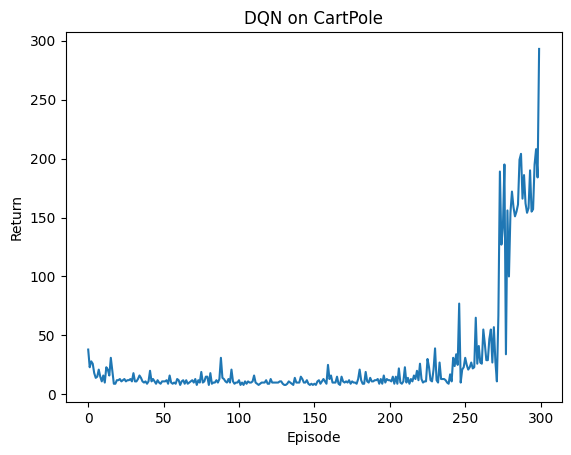

In [45]:
#| code-fold: true
#| code-summary: Solution - DQN training loop

from tqdm import trange

episodes = 300

# Initialized the environment
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Initialize the DQN agent and buffer
agent = DQNAgent(state_dim, n_actions)
batch_size=64
target_update_freq=1000

replay = ReplayBuffer(capacity = 50000)

# We keep track of the number of total steps for the
# target network update
total_steps = 0

# We keep track of the amount of rewards
returns = []  

pbar = trange(episodes, desc="Training DQN", leave=True)

for ep in pbar:
    
    s, _ = env.reset() 
    ep_return = 0
    done = False

    while not done:
        # act
        a = agent.act(s)
        
        s2, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        # store transition
        replay.push(s, a, r, s2, done)
        s = s2
        ep_return += r
        total_steps += 1

        # update networks
        agent.update(replay, batch_size)

        if total_steps % target_update_freq == 0:
            agent.update_target()

    # logging
    returns.append(ep_return)
    
    pbar.set_postfix(
        return_=f"{ep_return:.1f}",
        eps=f"{agent.epsilon():.3f}"
    )

plt.plot(returns)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DQN on CartPole")
plt.show()


:::